### Homework 3
Kai Rothe, Karim Zaghw

**1.** For a constant $c$, show that $E[(s-c)^2] = (c-E[s])^2 + Var[s]$. (2 points)

$$
\begin{gathered}
E[(s-c)^2] = & E[s^2 - 2 s c + c^2] \\\\
& E[s^2] - 2 c E[s] + c^2 \\\\
& E[s^2] - 2 c E[s] + c^2 + E[s]^2 - E[s]^2 \\\\
& (c^2 - 2 c E[s] + E[s]^2) + (E[s^2] - E[s]^2) \\\\
& (c - E[s])^2 + Var[s] \\\\
\end{gathered}
$$

**2.** Let $X \sim Poisson(\lambda)$.

**(a)**
Plot in Python the probability mass function (p.m.f.) of X for λ = 1; 5; 10; 50. What do you observe
about the shape of the p.m.f. as λ grows?
*(1 point)*

**(b)**
What are the parameters of the best matching Normal distribution for
a given Poisson distribution with parameter λ? No formal derivation is required here, use your intuition and verify by plotting (for the same values of
λ as above).
(1 point)

**Solutions**

**(a)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm
import seaborn as sns

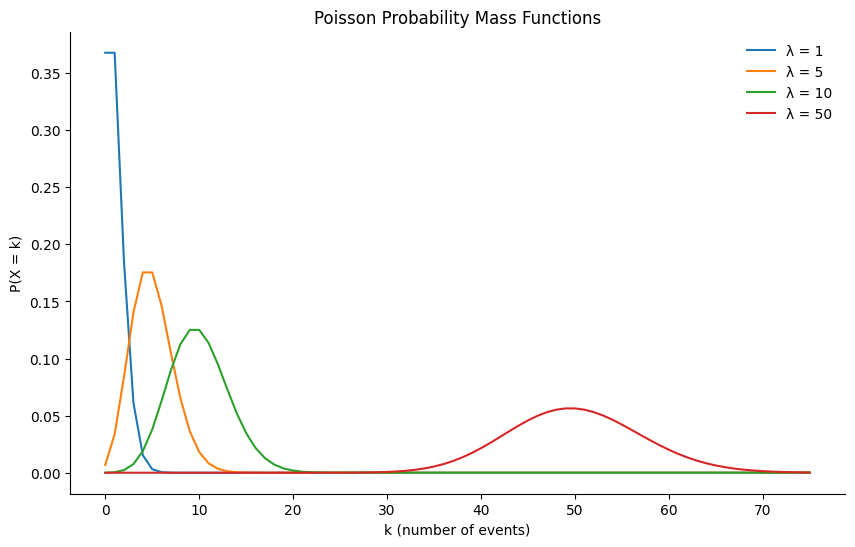

In [4]:
lambdas = [1, 5, 10, 50]

k_max = max(lambdas) * 1.5
k = np.arange(0, int(k_max) + 1)

plt.figure(figsize=(10, 6))
for lam in lambdas:
    pmf = poisson.pmf(k, mu=lam)
    plt.plot(k, pmf, linestyle='-', label=f'λ = {lam}')

plt.title('Poisson Probability Mass Functions')
plt.xlabel('k (number of events)')
plt.ylabel('P(X = k)')
plt.legend(frameon=False)
sns.despine()
plt.show()

As $\lambda$ grows, the maximum (i.e. as measured here by the mean $\lambda$) and spread (i.e. as measured here as the varience $\lambda$) of the p.m.f. increases. While the p.m.f. looks skewed for small $\lambda \leq 5$, it becomes symmetrical and Gaussian like for larger $\lambda \geq 10$.

**(b)**

For the Possion distribution, $\mu = \sigma^2 = \lambda$ for all $\lambda$. This should still hold in the limit of large $\lambda \rightarrow \infty$. It thus makes sense to use also a Normal Distribution with mean $\mu = \lambda$ and variance $\sigma^2 = \lambda$. 

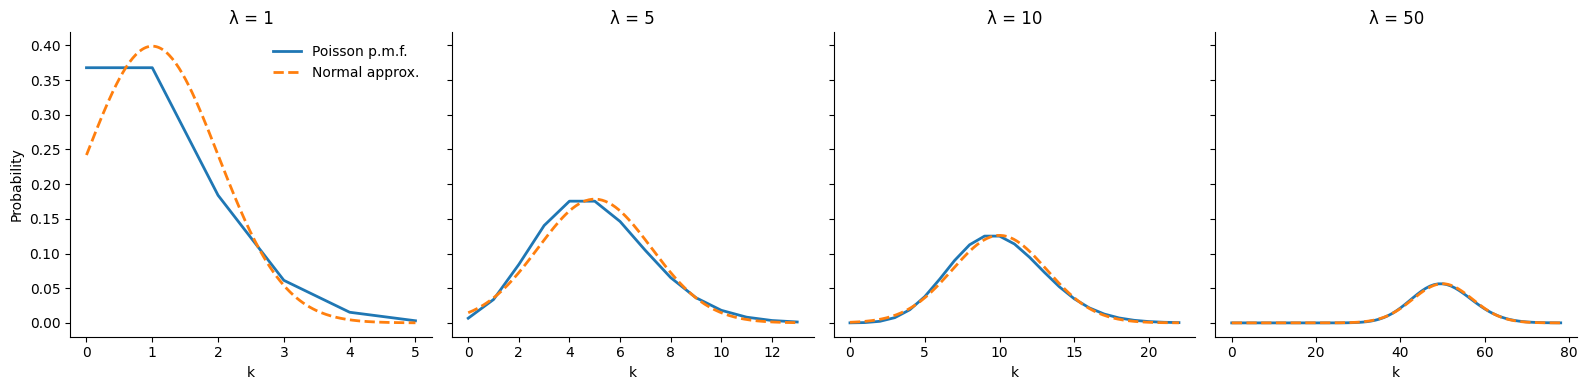

In [17]:
fig, axes = plt.subplots(1, len(lambdas), figsize=(16, 4), sharey=True)

for ax, lam in zip(axes, lambdas):
    k_max = int(lam + 4 * np.sqrt(lam))
    k = np.arange(0, k_max + 1)
    
    pmf = poisson.pmf(k, mu=lam)
    ax.plot(k, pmf, linestyle='-', label='Poisson p.m.f.', lw=2)
    
    x = np.linspace(0, k_max, 200)
    normal_pdf = norm.pdf(x, loc=lam, scale=np.sqrt(lam))
    ax.plot(x, normal_pdf, linestyle='--', label='Normal approx.', lw=2)
    
    ax.set_title(f'λ = {lam}')
    ax.set_xlabel('k')
    if lam == lambdas[0]:
        ax.set_ylabel('Probability')
        ax.legend(frameon=False, loc='upper right')
    sns.despine()

plt.tight_layout()
plt.show()

We can see that as $\lambda$ increases, the Normal approximation fit of the Poisson p.m.f. improves, with no observable difference for $\lambda = 50$. This validates our choice of mean and variance.

**3. Noise models**

Assume a tuning curve $f(s)$ with stimulus angle $s \in [-\pi, \pi]$:
$$f(s) = \begin{cases}
    - f_{max} \tfrac4{\pi^2} (s-\tfrac\pi2) (s + \tfrac\pi2) &\quad s \in [-\tfrac\pi2, \tfrac\pi2]\\
    0 &\quad else
\end{cases} $$
In each subtask the firing rate $r$ is given by a different noise model. For a discreticed interval (50 bins) for $s$ into, draw 10 samples from $p(r|f(s))$. Do this for different $f_{max} = 1; 10; 100$, and plot the rates, their mean $\pm$ sem (standard error of the mean), and the analytical function.
(1.5 points for each subtask)

**(a)** Additive normal noise
$$p(r|f(s)) \sim N(\mu, \sigma^2)$$
with $\mu=f(s)$, $\sigma=1$.

**(b)** Multiplicative normal noise
$$p(r|f(s)) \sim N(\mu, \sigma^2)$$
with $\mu=f(s)$, $\sigma=f(s)$.

**(c)** Poisson noise
$$p(r|f(s)=\frac{f(s)^r}{r!} e^{-f(s)}$$

**(d)** Negative Binomial
$$p(r|q,p)= {{r+q-1}\choose{r}} (1-p)^q p^r$$
with $p=\frac{f(s)}{f(s)+q}$, $q=f(s)$.
Be careful about the case when $p = 0$.

**(e)** Based on your results, briefly discuss how realistic each of these models is. (1 point)

In [75]:
f_max_list = [1, 10, 100]
num_bins = 50
s_interval = np.linspace(-np.pi, np.pi, num_bins + 1, endpoint=True)
n_samples = 10

def tuning_curve(s, f_max):
    f = np.zeros_like(s)
    mask = np.abs(s) <= np.pi / 2
    f[mask] = -f_max * 4 / (np.pi ** 2) * (s[mask] - np.pi / 2) * (s[mask] + np.pi / 2)
    return f

f_vals = {fv: tuning_curve(s_interval, fv) for fv in f_max_list}

def plot_samples(samples, title=None):
    fig, axes = plt.subplots(1, len(f_max_list), figsize=(10, 3), constrained_layout=True, dpi=300)
    fig.suptitle(title, fontsize=14)
    for i, f_max in enumerate(f_max_list):
        f = f_vals[f_max]
        
        mean = np.mean(samples[i], axis=0)
        sem = np.std(samples[i], axis=0, ddof=1) / np.sqrt(n_samples)
        
        axes[i].plot(s_interval, mean, label='Sampled Rates', lw=2)
        axes[i].plot(s_interval, f, label='Analytical Function', lw=2, linestyle="--")
        axes[i].fill_between(s_interval, mean - sem, mean + sem, alpha=0.2)   
        axes[i].set_title(f"$f_{{max}}$ = {f_max}")
        axes[i].set_xlabel("Stimulus angle $s$")
        axes[i].set_ylim(axes[i].get_ylim()[0], max(axes[i].get_ylim()[1], 2.3))
        if i == 0:
            axes[i].set_ylabel("Firing rate $r$")
            axes[i].legend(frameon=False, loc="upper left")
    
    sns.despine()


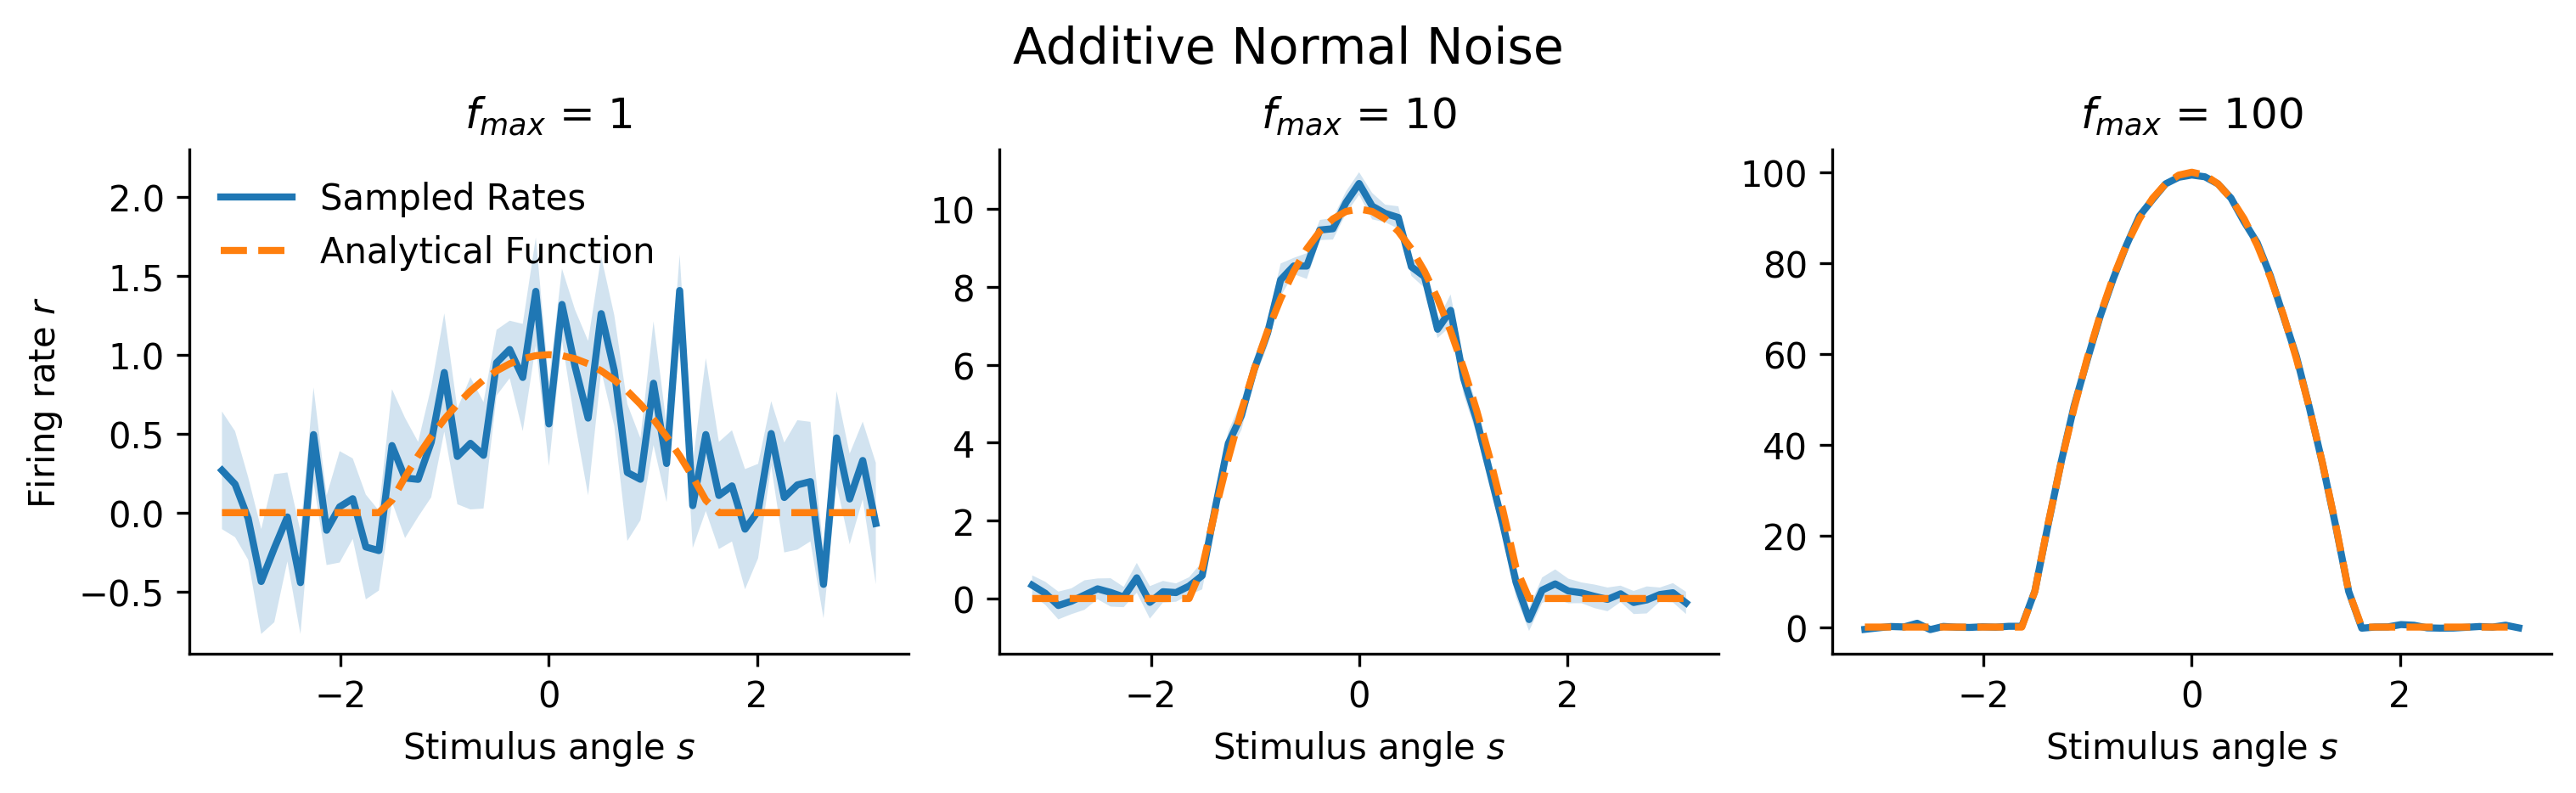

In [84]:
# (a) Additive normal noise
samples = []
for f_max in f_max_list:
    samples.append([np.random.normal(loc=f_vals[f_max], scale=1) for _ in range(n_samples)])
samples = np.array(samples)
plot_samples(samples, title="Additive Normal Noise")

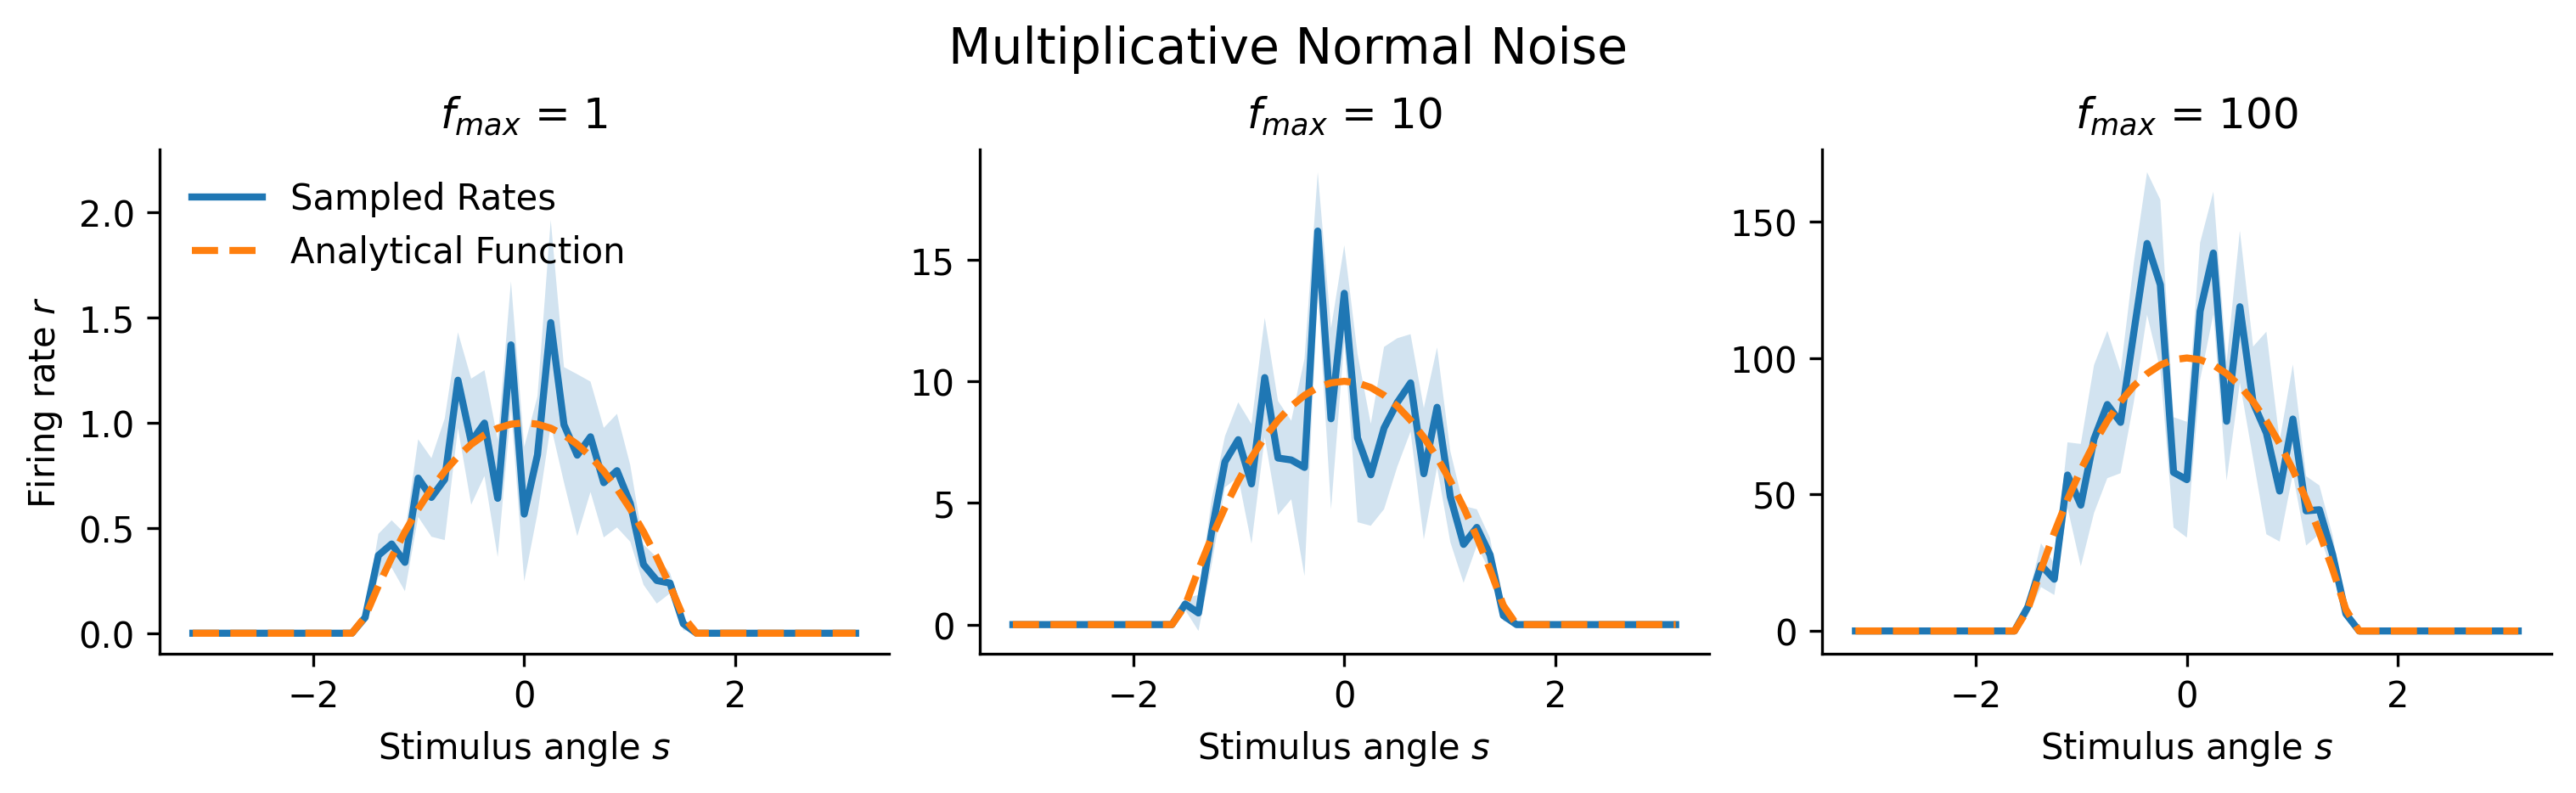

In [77]:
# (b) Multiplicative normal noise
samples = []
for f_max in f_max_list:
    samples.append([np.random.normal(loc=f_vals[f_max], scale=f_vals[f_max]) for _ in range(n_samples)])
samples = np.array(samples)
plot_samples(samples, title="Multiplicative Normal Noise")

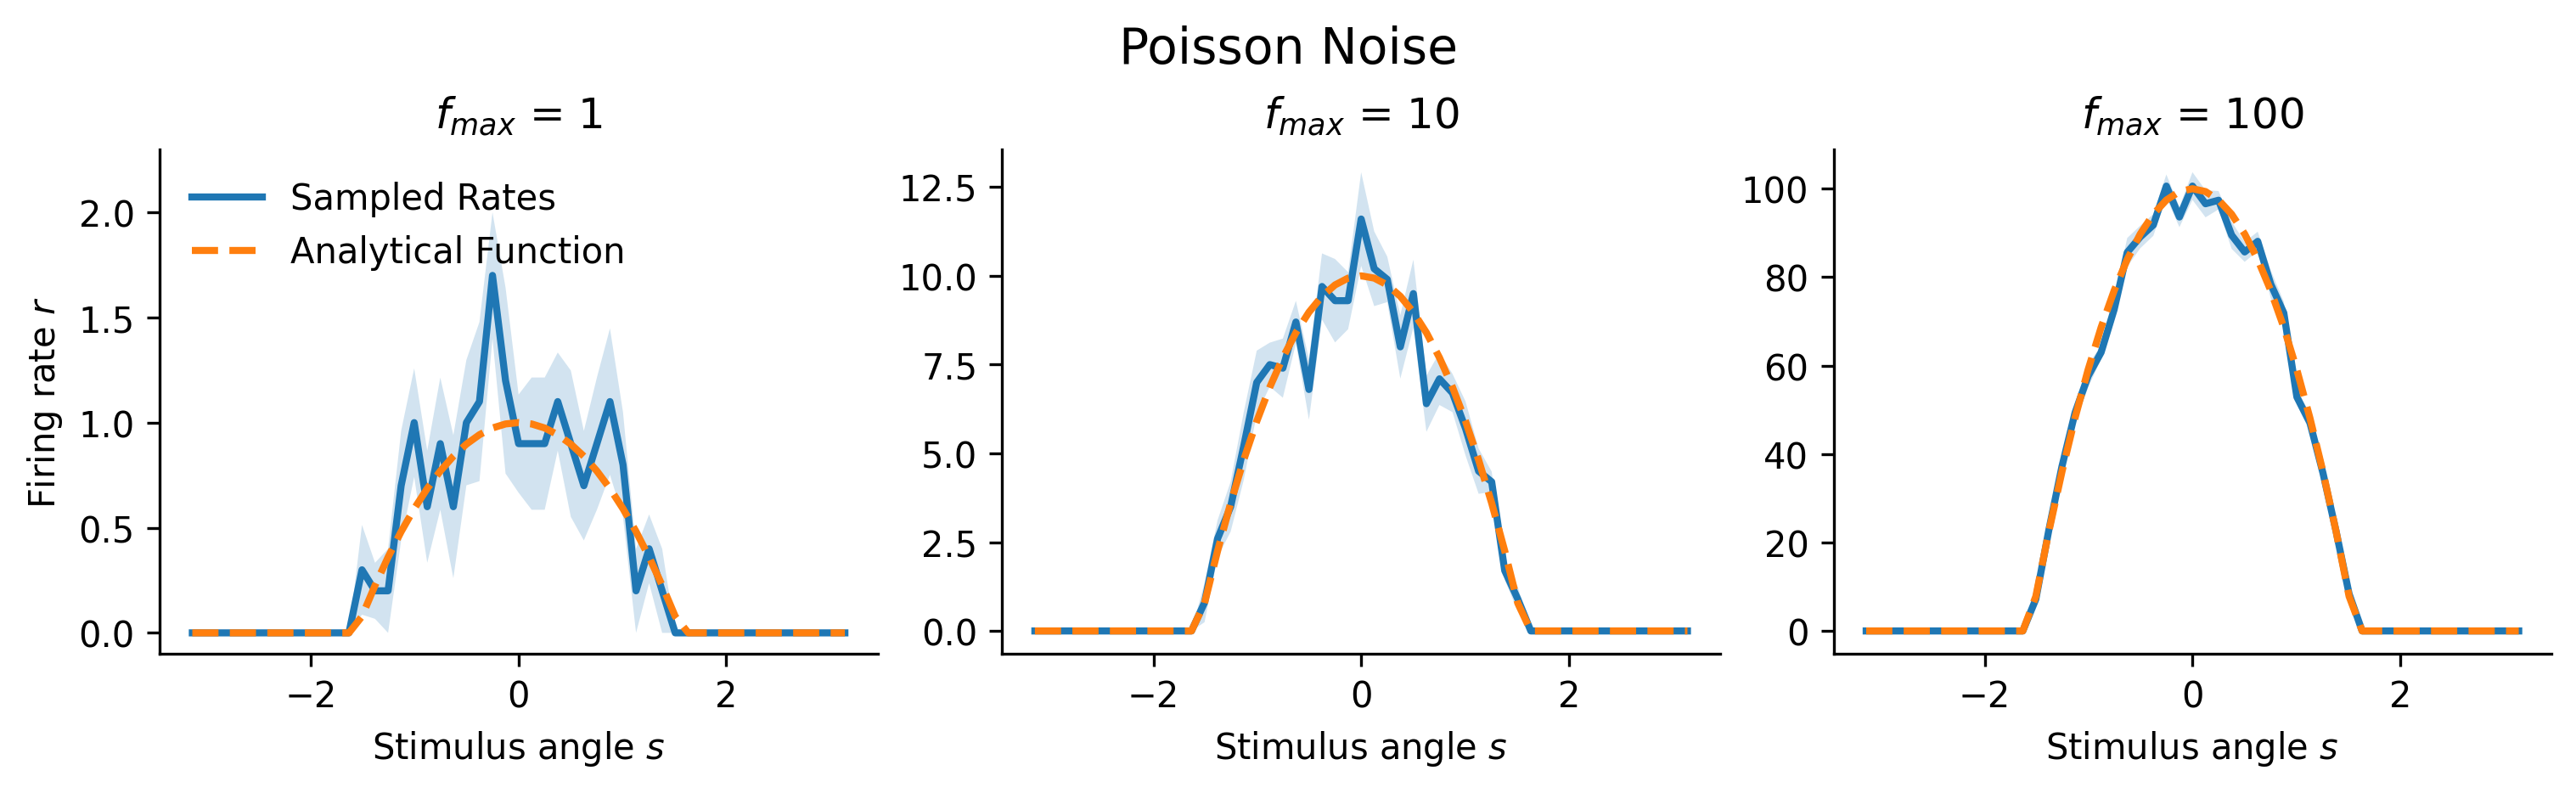

In [78]:
# (c) Poisson noise

samples = []
for f_max in f_max_list:
    samples.append([np.random.poisson(f_vals[f_max]) for _ in range(n_samples)])
samples = np.array(samples)
plot_samples(samples, title="Poisson Noise")

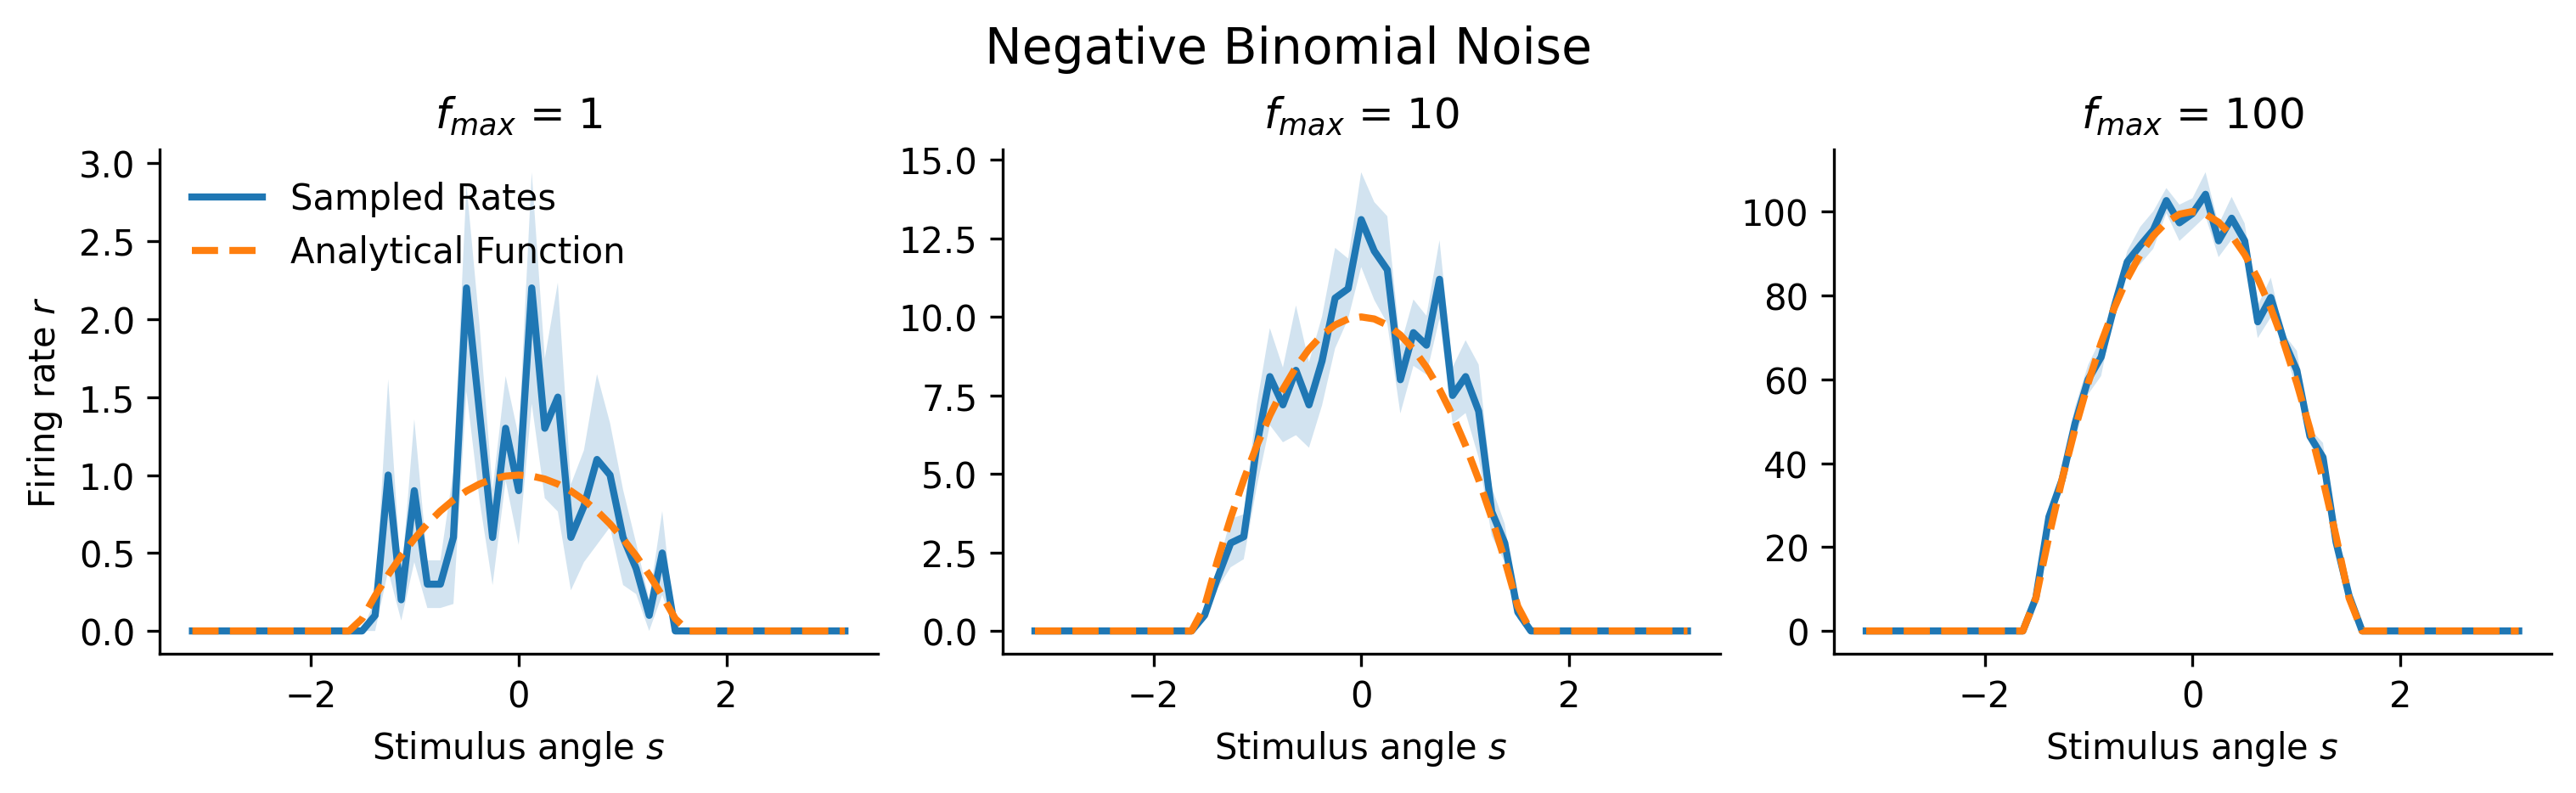

In [79]:
# (d) Negative binomial

samples = []
for f_max in f_max_list:
    f = f_vals[f_max]
    
    q = f
    p = np.zeros_like(f)
    mask = (f + q) > 0
    p = f[mask] / (f[mask] + q[mask])
    not_p = 1 - p  # for numpy 
    
    s = np.zeros((n_samples, len(f)))
    mask = f != 0
    for i in range(n_samples):
        s[i, mask] = np.random.negative_binomial(n=q[mask], p=not_p)
    samples.append(s)

samples = np.array(samples)
plot_samples(samples, title="Negative Binomial Noise")


#### 1. Additive Gaussian Noise
- **Support violation**: We observe negative firing rates, which are biologically implausible. Truncating or rectifying would alter the mean and variance in a stimulus-dependent way.
- **Constant variance**: Variance is fixed at 1 regardless of firing rate, so for high firing rate ($f_{{max}} = 100$) we observe nearly no relative (due to the axis scaling) variance. This does not match real neural data where variability typically increases for higher firing rates (Fano factor ≥ 1). 

#### 2. Multiplicative Gaussian Noise
- **Support violation**: Also allows negative values unless rectified, which distorts the distribution, see 1. But effect is less observed (compared to additive Gaussian noise) due to smaller variance for small firing rates. 
- **Overestimates variability**: Variance scales as $f(s)^2$, which is observed for large firing rates to heavily obscure the underlying tuning curve. Variance grows faster than typical neural variability, since most neurons exhibit approximately linear scaling of variance with mean, not quadratic. 

#### 3. Poisson Noise
- **Discrete values**: Models spike counts (integers), not continuous rates. Requires averaging in bins to interpret as a rate.
- **Fixed mean-variance relation**: Enforces $\mathrm{Var}[r] = \mathbb{E}[r]$, which underestimates variability in overdispersed real neurons (Fano factor > 1).
- **No temporal structure**: Assumes memoryless spiking (exponential interspike intervals), which neglects i.a. refractory periods.

#### 4. Negative Binomial Noise
- **Discrete values**: outputs integer spike counts like Poisson noise, see 3.
- **Flexible overdispersion**: Allows $\mathrm{Var}[r] > \mathbb{E}[r]$ via dispersion parameter $q$, which matches empirical Fano factors > 1.
- **Still memoryless**: Captures overdispersion but not spike history effects like refractory periods, see 3.